# Distribuții ale variabilelor aleatoare

Laboratorul 2, DEDP

# 1. Obiectiv

Generarea în Matlab a unor eșantioane cu distribuții uniforme și
normale, cu diferiți parametri. Calcularea probabilităților teoretice și
din vectori de eșantioane. Crearea de histograme. Folosirea funcției
`erf()` pentru funcția de repartiție normală.

# 2. Considerații teoretice

## 2.1 Densitate de probabilitate

În acest laborator considerăm **variabile aleatoare continue**.

O variabilă aleatoare continuă $A$ este descrisă de o **funcție
densitate de probabilitate** (PDF) $w_A(x)$, care arată cât de probabil
este ca $A$ să ia valori în jurul lui $x$. Densitatea de probabilitate
mai este numită și **distribuția** lui $A$.

Probabilitatea ca $A$ să se afle în intervalul $[a,b]$ este **aria de
sub PDF** pe acel interval, adică integrala PDF de la $a$ la $b$:

$$P(a<A\le b)=\int_a^b w_A(x)\,dx,$$

Probabilitatea se calculează numai pentru **intervale** de valori.
Probabilitatea ca $A$ să fie exact egală cu o anumită valoare este
întotdeauna zero.

<figure>
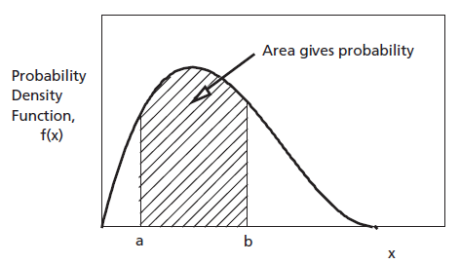
<figcaption aria-hidden="true">Probabilitatea = aria de sub
densitate</figcaption>
</figure>

PDF satisface întotdeauna $w_A(x)\ge 0$, iar integrala sa este 1, însă
valorile sale pot fi mai mari decât 1.

**Funcția de repartiție** (CDF) este definită ca probabilitatea ca
$A \le x$:

$$
F_A(x)=P(A\le x)
$$

CDF este nedescrescătoare și ia valori între 0 și 1.

CDF poate fi folosită și pentru a calcula probabilități pe intervale:

$$
P(a<A\le b)=F_A(b)-F_A(a).
$$

Cele două funcții sunt legate. PDF este derivata CDF:

$$
w_A(x)=\frac{dF_A(x)}{dx} \qquad \qquad F_A(x)=\int_{-\infty}^{x} w_A(t)\,dt.
$$

### Eșantioane aleatoare

O valoare sau un vector cu $N$ valori generate dintr-o anumită
distribuție reprezintă un **eșantion aleator**:

$$x = [x_1, x_2, \ldots, x_N].$$

Valorile se schimbă la fiecare rulare, dar comportamentul lor statistic
ar trebui să rămână același.

Media și varianța (sau deviația standard) calculate dintr-un anumit
vector de eșantioane se numesc **media eșantionului** și **varianța
eșantionului** (sau deviația standard a eșantionului).

``` matlab
% Media, deviația standard și varianța eșantionului, calculate din date
sample_mean = mean(x_normal)
sample_std = std(x_normal)
sample_var = var(x_normal)
```

Media și varianța eșantionului sunt apropiate, dar nu exact egale cu
media și varianța teoretică ale distribuției (sunt „estimări” ale
acestor valori teoretice).

## 2.2 Distribuția uniformă

### Definiție și parametri

Distribuția uniformă descrie o variabilă aleatoare care are șanse egale
să ia orice valoare dintr-un interval dat $[a,b]$.

Se notează:

$$A \sim \mathcal{U}[a,b], \qquad \textrm{  unde  } a < b.$$

Funcția sa densitate de probabilitate (PDF) este definită astfel:

$$
f_A(x) =
\begin{cases}
\dfrac{1}{b-a}, & a \le x \le b, \\
0, & \text{în rest}.
\end{cases}
$$

PDF este constantă pe $[a,b]$.

<figure>
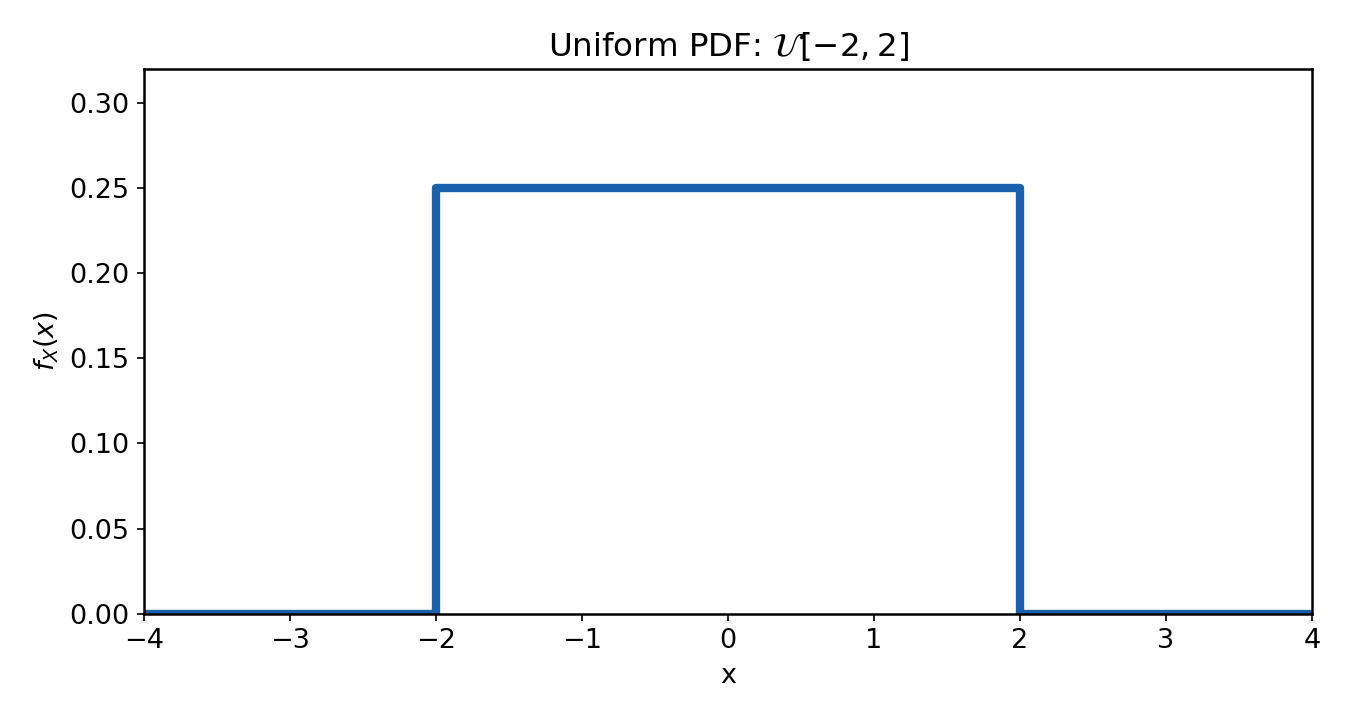
<figcaption aria-hidden="true">PDF pentru <span
class="math inline">𝒰[−2, 2]</span>.</figcaption>
</figure>

Media și varianța sa statistică sunt

$$
\mathrm{E}\{A\} = \frac{a+b}{2},
\qquad
\sigma_A^2 = \frac{(b-a)^2}{12}.
$$

### Generarea eșantioanelor uniforme în Matlab

`rand()` generează valori uniforme cu $0<A<1$. Nu contează dacă valorile
extreme $0$ și $1$ sunt incluse sau nu, deoarece oricum există o
infinitate de valori în interval.

``` matlab
A = rand()          % o valoare din U[0,1]

A = rand(1, 10)     % vector linie cu 10 valori independente din U[0,1]
```

Pentru a obține valori dintr-un interval general $[a,b]$, scalați și
deplasați valorile:

$$B = a + (b-a)A, \qquad A \sim \mathcal{U}[0,1].$$

``` matlab
a = 5;
b = 7;
N = 1000;

x_uniform = a + (b-a)*rand(1, N);
```

Aici, $b-a$ stabilește lățimea, iar $a$ stabilește limita inferioară.

### Probabilități pentru distribuția uniformă

Probabilitățile sunt arii de sub PDF.

Pentru o variabilă uniformă, calcularea probabilităților se reduce la
calcularea ariei unui dreptunghi și se poate face ușor.

Exemplu: pentru $X \sim \mathcal{U}[2, 10]$, probabilitatea ca $X$ să
fie între 3 și 5 este $\frac{2}{8} = 0.25$.

## 2.3 Distribuția normală

### Definiție și parametri

Distribuția normală descrie o variabilă aleatoare care ia mai probabil
valori apropiate de media sa $\mu$ decât valori îndepărtate, conform
unei PDF în formă de clopot („clopotul lui Gauss”).

O variabilă normală se notează:

$$X \sim \mathcal{N}(\mu,\sigma^2), \qquad \sigma > 0.$$

Funcția sa densitate de probabilitate este

$$
f_X(x) = \frac{1}{\sigma\sqrt{2\pi}}
\exp\left[-\frac{(x-\mu)^2}{2\sigma^2}\right].
$$

<figure>
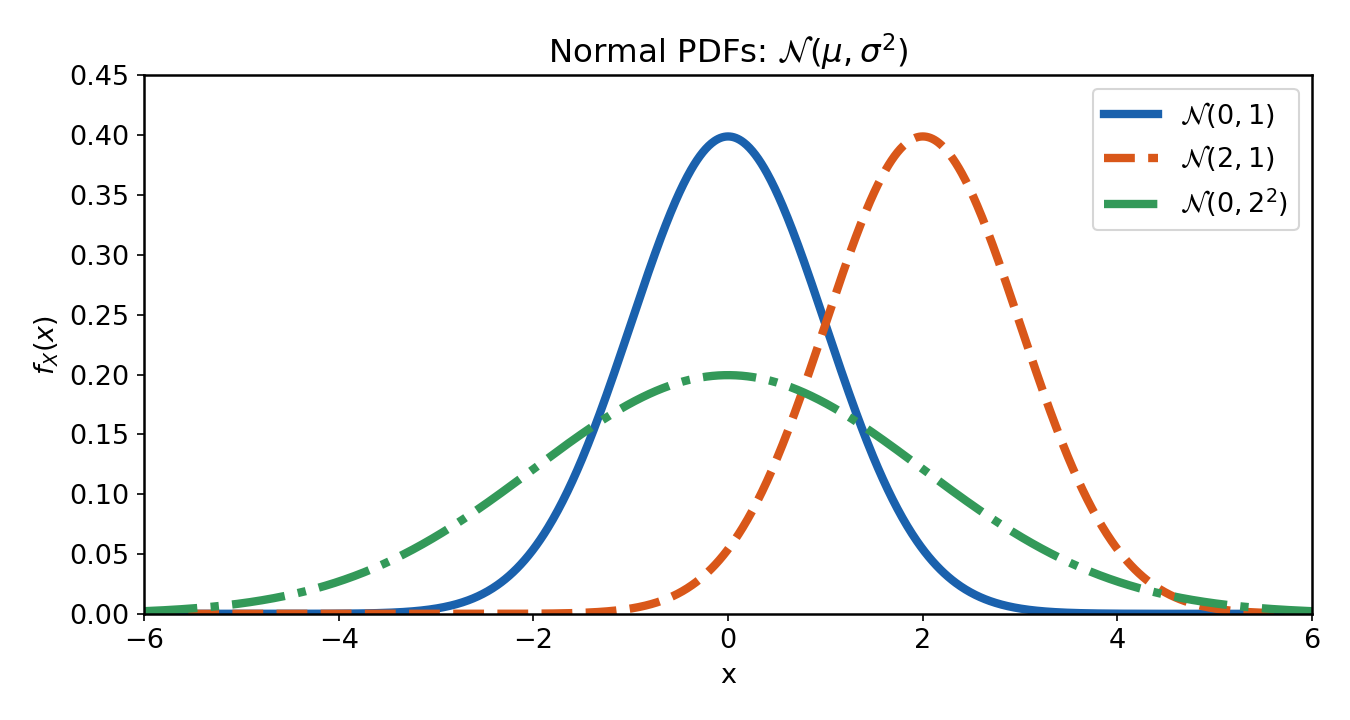
<figcaption aria-hidden="true">Modificarea lui <span
class="math inline"><em>μ</em></span> deplasează PDF normală; creșterea
lui <span class="math inline"><em>σ</em></span> o face mai lată și mai
aplatizată.</figcaption>
</figure>

Parametrii sunt:

- $\mu$: media (centrul);
- $\sigma^2$: varianța;
- $\sigma = \sqrt{\sigma^2}$: abaterea standard.

Modificarea lui $\mu$ înseamnă deplasarea PDF. Un $\sigma$ mai mare
înseamnă o funcție mai lată și mai aplatizată, iar un $\sigma$ mai mic
înseamnă una mai îngustă și mai înaltă.

**Distribuția normală standard** este distribuția normală cu $\mu=0$ și
$\sigma=1$:

$$Z \sim \mathcal{N}(\mu=0,\sigma^2=1).$$

### Generarea eșantioanelor normale în Matlab

`randn()` generează valori din distribuția normală standard
$\mathcal{N}(\mu=0,\sigma^2=1)$:

``` matlab
z = randn()          % o valoare din N(0,1)

z = randn(1, 10)     % 10 valori independente din N(0,1)
```

Pentru valori arbitrare $\mu$ și $\sigma$, scalați cu $\sigma$ și
deplasați cu $\mu$:

$$B = \mu + \sigma A, \qquad \text{ unde } A \sim \mathcal{N}(\mu=0,\sigma^2=1).$$

``` matlab
mu = 5;
sigma = 2;
N = 1000;

x_normal = mu + sigma*randn(1, N);
```

Notă: înmulțiți cu abaterea standard $\sigma$, nu cu varianța
$\sigma^2$.

### Calcularea probabilităților pentru distribuția normală

Integrala din densitatea de probabilitate normală nu poate fi calculată
analitic. În schimb, folosim funcția predefinită `erf()` din Matlab
pentru acest scop.

Pentru o variabilă normală $A \sim \mathcal{N}(\mu,\sigma^2)$,
probabilitatea ca $A$ să se afle în intervalul $[a,b]$ este:

$$P(a \le A \le b) = F_A(b) - F_A(a),$$

unde $F_A(x)$ este funcția de repartiție (CDF) a lui $A$ și se
calculează folosind funcția de eroare `erf()`:

$$
F_A(x) = P(A \le x) = \frac{1}{2}\left[1 + \operatorname{erf}\left(\frac{x-\mu}{\sigma\sqrt{2}}\right)\right].
$$

În Matlab:

Exemplu: $A \sim \mathcal{N}(\mu=10,\sigma^2=4)$ și $P(8 \le X \le 12)$:

``` matlab
mu = 10;
sigma = 2;
a = 8;
b = 12;

F_a = 0.5*(1 + erf((a-mu)/(sigma*sqrt(2))));
F_b = 0.5*(1 + erf((b-mu)/(sigma*sqrt(2))));
p_normal_theory = F_b - F_a
```

Rezultatul este aproximativ 0.6827. Probabilitatea poate fi estimată și
din eșantioane, empiric:

``` matlab
N = 10000;
x_normal = mu + sigma*randn(1, N);
p_normal_estimated = sum(x_normal >= a & x_normal <= b)/N;
```

## 2.4 Histogramele ca reprezentare vizuală a distribuțiilor

O **histogramă** este un grafic cu bare care afișează distribuția
eșantioanelor, numărând câte eșantioane se află in fiecare interval de
valori. În Matlab, se poate folosi funcția `histogram()`:

``` matlab
% Generează 10000 de eșantioane dintr-o distribuție uniformă pe [-4, 10]
x_uniform = -4 + 14*rand(1, 10000);

% Afișează o histogramă cu 30 de clase
histogram(x_uniform, 30)
xlabel('Valoare')
ylabel('Număr de eșantioane')
title('Eșantioane uniforme')
grid on
```

Pentru a o compara cu o PDF, trebuie să-i normalizăm aria la 1, folosind
opțiunea `'Normalization','pdf'`:

``` matlab
% Generează 10000 de eșantioane dintr-o distribuție normală cu media 5 și abaterea standard 2
x_normal = 5 + 2*randn(1, 10000);

% Afișează o histogramă normalizată ca PDF, cu 35 de clase
histogram(x_normal, 35, 'Normalization', 'pdf')
xlabel('Valoare')
ylabel('Densitate de probabilitate estimată')
title('Eșantioane normale')
grid on
```

Histogramele sunt o metodă practică de a vizualiza distribuția
eșantioanelor (valori, pixeli etc.) pentru a înțelege datele.

## 2.5 Rezumat: funcții și notații pe care trebuie să le cunoașteți

| Signatură sau notație | Exemplu | Descriere |
|------------------------|------------------------|------------------------|
| $X \sim \mathcal{U}[a,b]$ | $X \sim \mathcal{U}[-4,10]$ | Distribuție uniformă pe $[a,b]$ |
| $X \sim \mathcal{N}(\mu,\sigma^2)$ | $X \sim \mathcal{N}(5,2^2)$ | Distribuție normală: media $\mu$, varianța $\sigma^2$ |
| `rand(m,n)` | `rand(1,1000)` | $m \times n$ eșantioane din $\mathcal{U}[0,1]$ |
| `a + (b-a)*rand(m,n)` | `-4 + 14*rand(1,1000)` | Eșantioane din $\mathcal{U}[a,b]$ |
| `randn(m,n)` | `randn(1,1000)` | $m \times n$ eșantioane din $\mathcal{N}(0,1)$ |
| `mu + sigma*randn(m,n)` | `5 + 2*randn(1,1000)` | Eșantioane din $\mathcal{N}(\mu,\sigma^2)$ |
| `mean(x)`, `std(x)`, `var(x)` | `mean(x)`, `std(x)`, `var(x)` | Media, abaterea standard și varianța eșantionului |
| `histogram(x,n)` | `histogram(x,30)` | Histogramă cu `n` clase; adăugați `'Normalization','pdf'` pentru arie unitară |
| `erf(x)` | `erf(1/sqrt(2))` | Funcția de eroare folosită în CDF normală |
| `sum(condition)/N` | `sum(x >= a & x <= b)/N` | Probabilitate empirică |

# 3. Exerciții

Scrieți singuri toate comenzile într-un script sau live script.
Etichetați figurile și răspundeți la întrebările de interpretare în
comentarii.

1.  Eșantioane aleatoare uniforme:

    1.  Generați $N=10000$ de eșantioane din $\mathcal{U}[-4,10]$.
    2.  Afișați valorile minime și maxime ale vectorului. De ce lipsesc
        valorile extreme? Și de ce acest lucru nu schimbă distribuția
        teoretică?
    3.  Comparați `mean()` cu $(a+b)/2$.
    4.  Reprezentați grafic primele 100 de valori generate folosind
        `plot()`.
    5.  Reprezentați o histogramă normalizată a datelor, cu 30 de
        intervale. Care este înălțimea sa teoretică?

2.  Efectul parametrilor distribuției uniforme:

    1.  Generați câte 10000 de eșantioane din $\mathcal{U}[0,1]$ și
        $\mathcal{U}[5,7]$.
    2.  Reprezentați histogramele normalizate, cu același număr de
        clase, în ferestre separate (`figure`).
    3.  Descrieți modificările poziției, lățimii și înălțimii PDF.

3.  Eșantioane aleatoare normale:

    1.  Stabiliți `mu1 = 2`, `sigma1 = sqrt(2)` și generați 10000 de
        eșantioane din $\mathcal{N}(\mu=2,\sigma^2=2)$ în `x_normal_1`.
        Al doilea parametru este varianța.
    2.  Reprezentați grafic primele 100 de valori din vector.
    3.  Reprezentați histograma tuturor valorilor.
    4.  Calculați media și abaterea standard ale eșantionului cu
        `mean()` și `std()` și comparați-le cu $2$ și $\sqrt{2}$. De ce
        nu sunt exact egale?
    5.  Păstrați `sigma1`, schimbați $\mu$ la $-3$ și comparați
        histogramele. Ce se schimbă?
    6.  Păstrați `mu1`, schimbați $\sigma$ la $0.5$ și comparați din
        nou.

4.  Probabilități pentru o variabilă uniformă:

    Fie $X \sim \mathcal{U}[-4,10]$.

    1.  Calculați teoretic $P(-1 \le X \le 3)$.
    2.  Estimați-o din Exercițiul 1 folosind comparații logice și
        `sum()`.
    3.  Calculați și estimați $P(X>7)$.
    4.  Repetați pentru $N=100$, $1000$ și $100000$. Cum tinde să se
        modifice eroarea? Trebuie să scadă la fiecare rulare?

5.  Probabilități pentru o variabilă normală folosind `erf()`:

    Fie $X \sim \mathcal{N}(\mu=2,\sigma^2=2)$.

    1.  Folosiți `erf()` pentru a calcula valorile teoretice ale
        $P(X \le 3)$, apoi $P(0 \le X \le 4)$ și apoi $P(X>5)$.
    2.  Estimați-le pe toate trei din `x_normal_1`.
    3.  Folosiți funcția `normcdf()` pentru a calcula aceleași
        probabilități (citiți documentația despre utilizarea ei).

## 3.1 Exerciții suplimentare

1.  Scrieți `p = myCDF(v, x)` pentru a estima $P(V \le x)$:

    $$\widehat{F}_V(x) = \frac{\text{numărul elementelor lui }v\text{ care sunt}\le x}
    {\text{numărul total de elemente ale lui }v}.$$

    Evaluați-o în 100 de puncte folosind o buclă `for`. Reprezentați
    estimările uniforme și normale împreună cu funcțiile lor de
    repartiție teoretice.

2.  Scrieți `p = myPDF(v, x, epsilon)` pentru a estima PDF în jurul lui
    `x` din eșantioanele aflate în $[x-\varepsilon,x+\varepsilon]$:

    $$
    \widehat{f}_V(x) =
    \frac{\text{numărul eșantioanelor din }[x-\varepsilon,x+\varepsilon]}
    {2\varepsilon\,N}.
    $$

    Încercați mai multe valori $\varepsilon$. Explicați compromisul
    dintre netezime și detalii.

# 4. Întrebări finale

1.  Poate o PDF să fie mai mare decât 1? De ce probabilitățile nu pot
    totuși să depășească 1?
2.  De ce o estimare din $N=1000$ de eșantioane poate fi mai slabă decât
    una din $N=100$?
3.  Două seturi de date au aceeași medie și varianță. Trebuie să aibă
    aceeași distribuție?
4.  Cum ați putea decide dacă datele măsurate sunt modelate mai bine de
    o distribuție uniformă sau de una normală?